In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [38]:
df = pd.read_csv("data/egx/ABUK.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print("\nShape:", df.shape)

        date       open       high        low      close  volume
0 2015-01-04  10.666666  10.666666  10.666666  10.666666       0
1 2015-01-05  10.666666  10.800000  10.373333  10.794666  295290
2 2015-01-06  10.794666  10.800000  10.800000  10.800000  765000
3 2015-01-08  10.800000  10.400666  10.400666  10.800000     255
4 2015-01-11  10.800000  10.800000  10.800000  10.800000       0

Shape: (2857, 6)


In [43]:
df["return"] = df["close"].pct_change()

print(df[["date", "close", "return"]].head(10))

        date      close    return
0 2015-01-05  10.794666       NaN
1 2015-01-06  10.800000  0.000494
2 2015-01-08  10.800000  0.000000
3 2015-01-11  10.800000  0.000000
4 2015-01-12  10.800000  0.000000
5 2015-01-13  10.800000  0.000000
6 2015-01-14  10.800000  0.000000
7 2015-01-15  10.796666 -0.000309
8 2015-01-18  10.565333 -0.021426
9 2015-01-19  10.534666 -0.002903


In [44]:
df = df.dropna(subset=["return"]).reset_index(drop=True)

print(df[["date", "return"]].head(10))

        date    return
0 2015-01-06  0.000494
1 2015-01-08  0.000000
2 2015-01-11  0.000000
3 2015-01-12  0.000000
4 2015-01-13  0.000000
5 2015-01-14  0.000000
6 2015-01-15 -0.000309
7 2015-01-18 -0.021426
8 2015-01-19 -0.002903
9 2015-01-20  0.025187


In [45]:
returns = df["return"].values.astype("float32")

window = 10

X = []
y = []

for i in range(window, len(returns)):
    X.append(returns[i-window:i])
    y.append(returns[i])

X = np.array(X, dtype="float32")
y = np.array(y, dtype="float32")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2845, 10)
y shape: (2845,)


In [26]:
df = df.dropna(subset=["next_return"])

X = df[["return"]].values.astype("float32")
y = df["next_return"].values.astype("float32")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 X values:")
print(X[:5])

print("\nFirst 5 y values:")
print(y[:5])

X shape: (2855, 1)
y shape: (2855,)

First 5 X values:
[[0.01200003]
 [0.00049412]
 [0.        ]
 [0.        ]
 [0.        ]]

First 5 y values:
[0.00049412 0.         0.         0.         0.        ]


In [46]:
print("First input window:")
print(X[0])

print("\nFirst target:")
print(y[0])

print("\nSecond input window:")
print(X[1])

print("\nSecond target:")
print(y[1])

First input window:
[ 0.00049412  0.          0.          0.          0.          0.
 -0.00030871 -0.02142632 -0.00290263  0.02518676]

First target:
0.0

Second input window:
[ 0.          0.          0.          0.          0.         -0.00030871
 -0.02142632 -0.00290263  0.02518676  0.        ]

Second target:
-0.022098841


In [47]:
split = int(len(X) * 0.7)

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1991
Testing samples: 854


In [48]:
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)

X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([1991, 10])
y_train: torch.Size([1991])
X_test: torch.Size([854, 10])
y_test: torch.Size([854])


In [58]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)

In [59]:
model = MLP()

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [74]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [75]:
epochs = 300

train_losses = []
test_losses = []

for epoch in range(epochs):

    # Forward pass
    train_prediction = model(X_train)

    # Calculate training loss
    train_loss = criterion(train_prediction, y_train)

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    train_loss.backward()

    # Update weights
    optimizer.step()

    # Evaluate on test data
    with torch.no_grad():
        test_prediction = model(X_test)
        test_loss = criterion(test_prediction, y_test)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss.item():.6f} | "
            f"Test Loss: {test_loss.item():.6f}"
        )

Epoch 50/300 | Train Loss: 0.000435 | Test Loss: 0.000752
Epoch 100/300 | Train Loss: 0.000435 | Test Loss: 0.000753
Epoch 150/300 | Train Loss: 0.000434 | Test Loss: 0.000754
Epoch 200/300 | Train Loss: 0.000434 | Test Loss: 0.000754
Epoch 250/300 | Train Loss: 0.000433 | Test Loss: 0.000754
Epoch 300/300 | Train Loss: 0.000432 | Test Loss: 0.000754


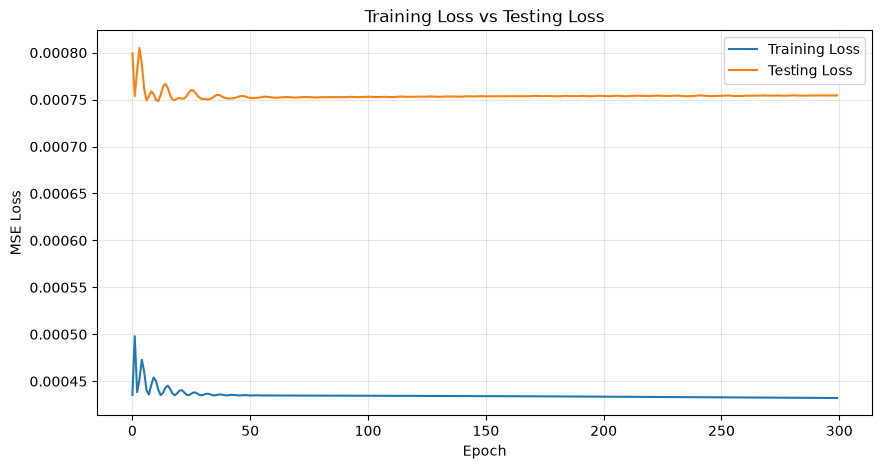

In [76]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss vs Testing Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [77]:
with torch.no_grad():
    train_predictions = model(X_train).numpy()
    test_predictions = model(X_test).numpy()

actual_train = y_train.numpy()
actual_test = y_test.numpy()

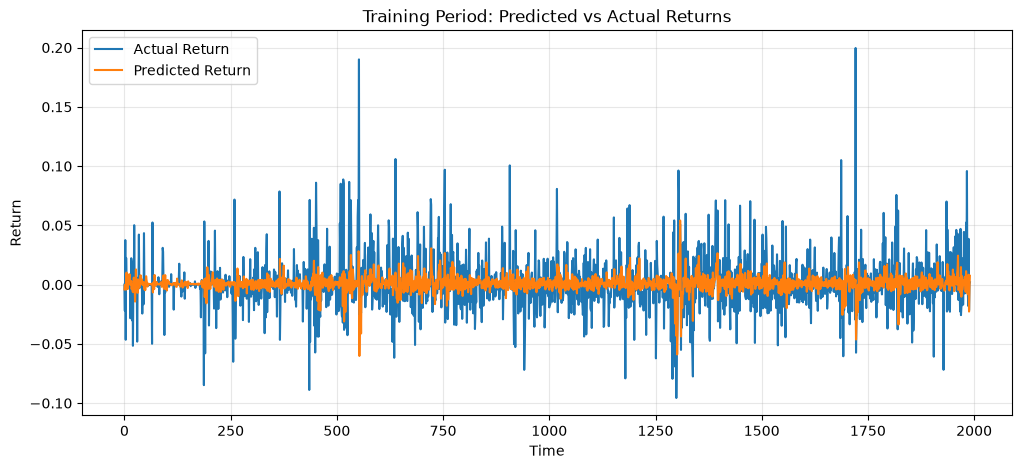

In [78]:
plt.figure(figsize=(12, 5))

plt.plot(actual_train, label="Actual Return")
plt.plot(train_predictions, label="Predicted Return")

plt.xlabel("Time")
plt.ylabel("Return")
plt.title("Training Period: Predicted vs Actual Returns")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

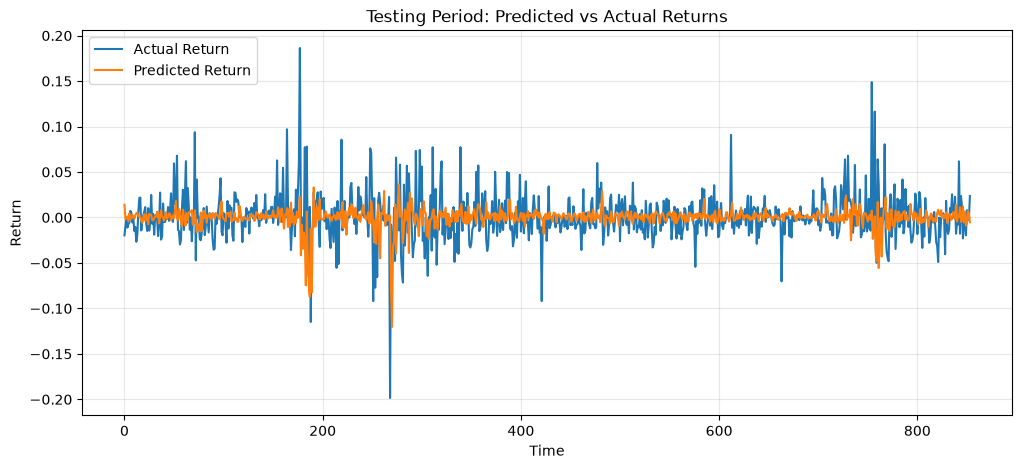

In [79]:
plt.figure(figsize=(12, 5))

plt.plot(actual_test, label="Actual Return")
plt.plot(test_predictions, label="Predicted Return")

plt.xlabel("Time")
plt.ylabel("Return")
plt.title("Testing Period: Predicted vs Actual Returns")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [80]:
results = pd.DataFrame({
    "actual_return": actual_test,
    "predicted_return": test_predictions
})

print(results.head(15).to_string(index=False))

 actual_return  predicted_return
     -0.019734          0.013972
     -0.009500         -0.001878
      0.000228         -0.000640
     -0.011187          0.001173
     -0.007158         -0.003385
     -0.005814          0.004507
      0.007251         -0.002338
      0.004877         -0.000819
     -0.005547          0.003009
     -0.001162          0.000679
     -0.014891         -0.001527
     -0.010392          0.002510
     -0.026730          0.004756
     -0.019127          0.005193
      0.006000          0.001525
